In [4]:
import pandas as pd

# Read the dataset
df = pd.read_csv(r"C:\Data\Fraud_Data.csv")


In [5]:
# Display the first 5 rows
print(df.head())

# Display dataset information
print(df.info())

# Display basic statistics
print(df.describe())

# Check dataset shape
print("Rows and Columns:", df.shape)

   user_id          signup_time        purchase_time  purchase_value  \
0    22058  2015-02-24 22:55:49  2015-04-18 02:47:11              34   
1   333320  2015-06-07 20:39:50  2015-06-08 01:38:54              16   
2     1359  2015-01-01 18:52:44  2015-01-01 18:52:45              15   
3   150084  2015-04-28 21:13:25  2015-05-04 13:54:50              44   
4   221365  2015-07-21 07:09:52  2015-09-09 18:40:53              39   

       device_id source browser sex  age    ip_address  class  
0  QVPSPJUOCKZAR    SEO  Chrome   M   39  7.327584e+08      0  
1  EOGFQPIZPYXFZ    Ads  Chrome   F   53  3.503114e+08      0  
2  YSSKYOSJHPPLJ    SEO   Opera   M   53  2.621474e+09      1  
3  ATGTXKYKUDUQN    SEO  Safari   M   41  3.840542e+09      0  
4  NAUITBZFJKHWW    Ads  Safari   M   45  4.155831e+08      0  
<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------  

In [6]:
import pandas as pd
import numpy as np

# Load data
#df = pd.read_csv("fraud_data.csv")

# Overview
print("Dataset Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())

print("\nFirst 5 Rows:")
print(df.head())

Dataset Shape: (151112, 11)

Missing Values:
user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

First 5 Rows:
   user_id          signup_time        purchase_time  purchase_value  \
0    22058  2015-02-24 22:55:49  2015-04-18 02:47:11              34   
1   333320  2015-06-07 20:39:50  2015-06-08 01:38:54              16   
2     1359  2015-01-01 18:52:44  2015-01-01 18:52:45              15   
3   150084  2015-04-28 21:13:25  2015-05-04 13:54:50              44   
4   221365  2015-07-21 07:09:52  2015-09-09 18:40:53              39   

       device_id source browser sex  age    ip_address  class  
0  QVPSPJUOCKZAR    SEO  Chrome   M   39  7.327584e+08      0  
1  EOGFQPIZPYXFZ    Ads  Chrome   F   53  3.503114e+08      0  
2  YSSKYOSJHPPLJ    SEO   Opera   M   53  2.621474e+09      1  
3  ATGTXKYKUDUQN  

In [7]:
# Check missing values
print(df.isnull().sum())

# Percentage of missing values
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent)

user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64
user_id           0.0
signup_time       0.0
purchase_time     0.0
purchase_value    0.0
device_id         0.0
source            0.0
browser           0.0
sex               0.0
age               0.0
ip_address        0.0
class             0.0
dtype: float64


In [9]:
df.shape

(151112, 11)

In [10]:
df.columns

Index(['user_id', 'signup_time', 'purchase_time', 'purchase_value',
       'device_id', 'source', 'browser', 'sex', 'age', 'ip_address', 'class'],
      dtype='str')

In [11]:
print(df.isnull().sum())

user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64


In [12]:
# Check for missing values
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

# Verify no missing values exist
print("\nTotal Missing Values:", missing_values.sum())

Missing Values:
user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

Total Missing Values: 0


In [13]:
# Check duplicates
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [15]:
# Check duplicates
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

Duplicate rows: 0


In [16]:
df['signup_time'] = pd.to_datetime(df['signup_time'])
df['purchase_time'] = pd.to_datetime(df['purchase_time'])

In [17]:
print(df.dtypes)

user_id                    int64
signup_time       datetime64[us]
purchase_time     datetime64[us]
purchase_value             int64
device_id                    str
source                       str
browser                      str
sex                          str
age                        int64
ip_address               float64
class                      int64
dtype: object


In [18]:
df['time_diff'] = (df['purchase_time'] - df['signup_time']).dt.total_seconds()

In [21]:
import matplotlib.pyplot as plt

df['class'].value_counts()

class
0    136961
1     14151
Name: count, dtype: int64

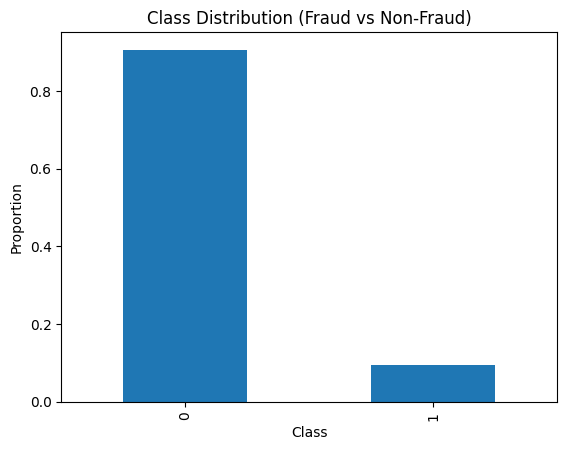

In [22]:
df['class'].value_counts(normalize=True).plot(kind='bar')
plt.title("Class Distribution (Fraud vs Non-Fraud)")
plt.xlabel("Class")
plt.ylabel("Proportion")
plt.show()

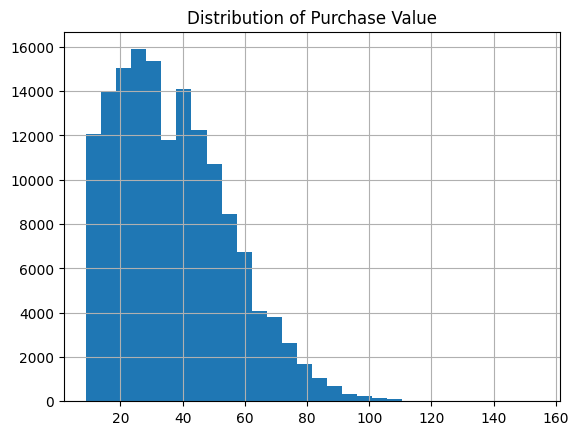

In [23]:
df['purchase_value'].hist(bins=30)
plt.title("Distribution of Purchase Value")
plt.show()

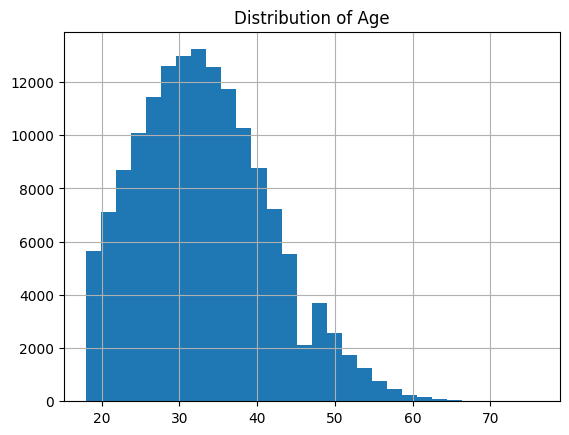

In [24]:
df['age'].hist(bins=30)
plt.title("Distribution of Age")
plt.show()

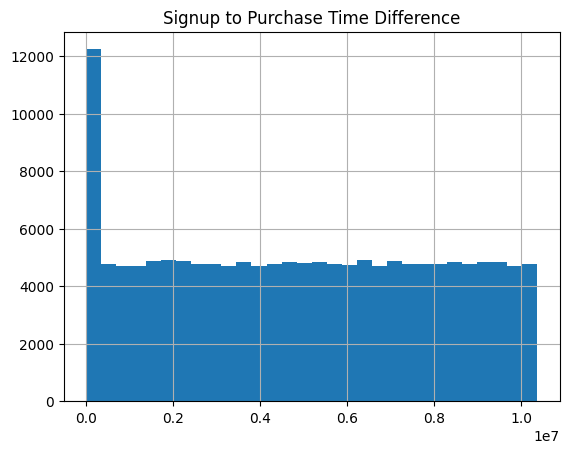

In [25]:
df['time_diff'].hist(bins=30)
plt.title("Signup to Purchase Time Difference")
plt.show()

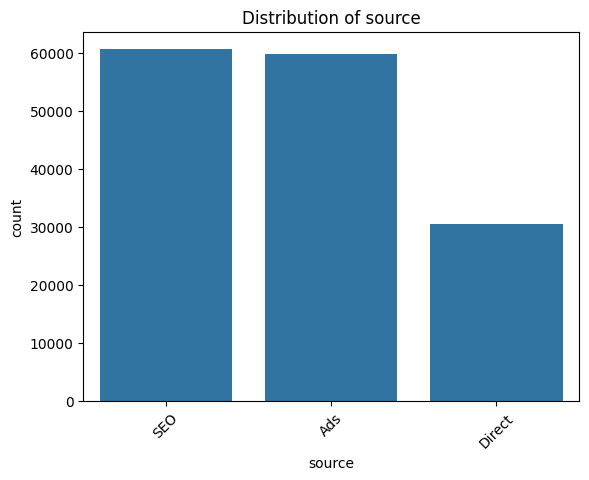

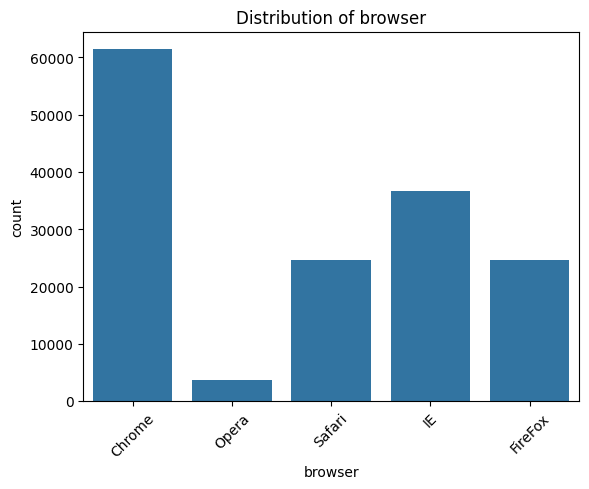

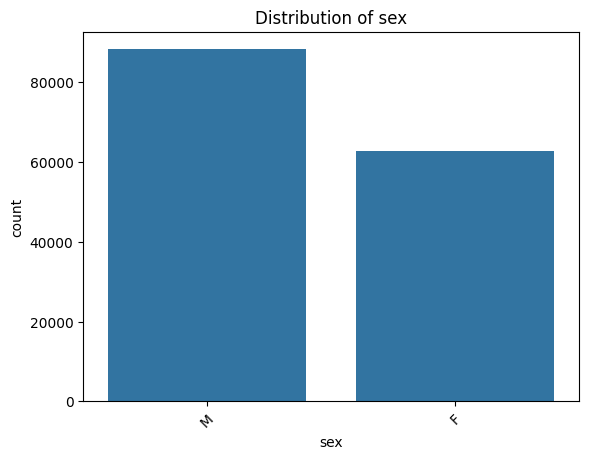

In [28]:
import seaborn as sns

cat_cols = ['source', 'browser', 'sex']

for col in cat_cols:
    sns.countplot(x=df[col])
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

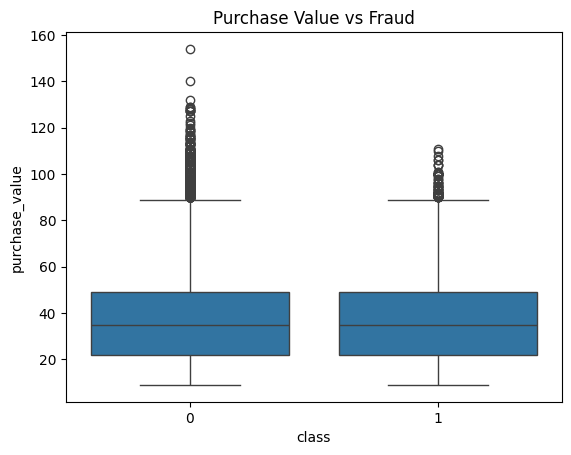

In [29]:
sns.boxplot(x='class', y='purchase_value', data=df)
plt.title("Purchase Value vs Fraud")
plt.show()

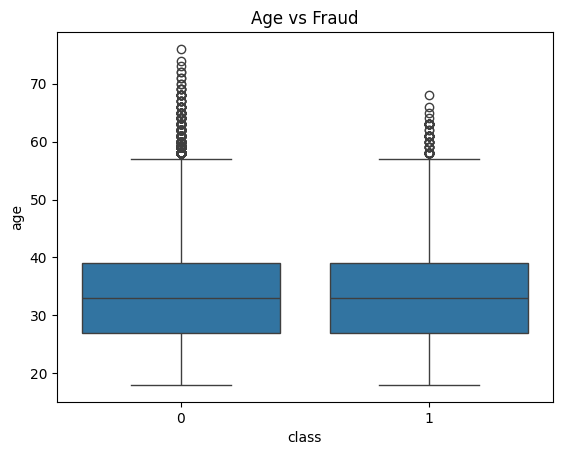

In [30]:
sns.boxplot(x='class', y='age', data=df)
plt.title("Age vs Fraud")
plt.show()

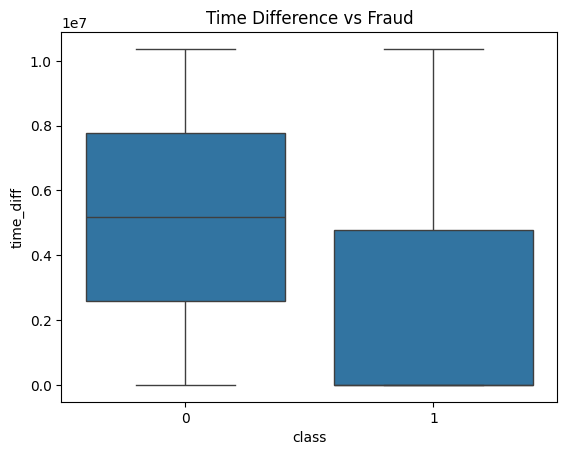

In [31]:
sns.boxplot(x='class', y='time_diff', data=df)
plt.title("Time Difference vs Fraud")
plt.show()

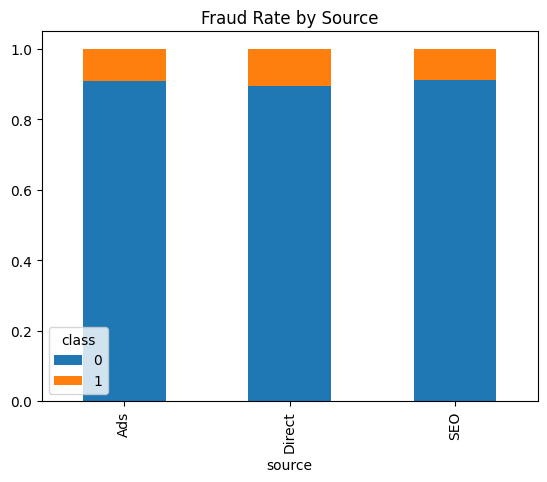

In [32]:
pd.crosstab(df['source'], df['class'], normalize='index').plot(kind='bar', stacked=True)
plt.title("Fraud Rate by Source")
plt.show()

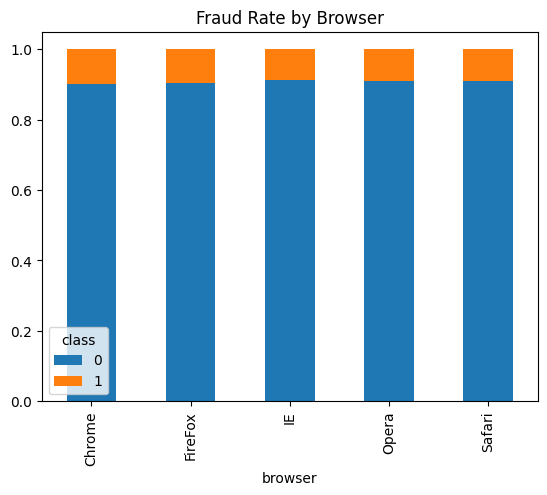

In [33]:
pd.crosstab(df['browser'], df['class'], normalize='index').plot(kind='bar', stacked=True)
plt.title("Fraud Rate by Browser")
plt.show()

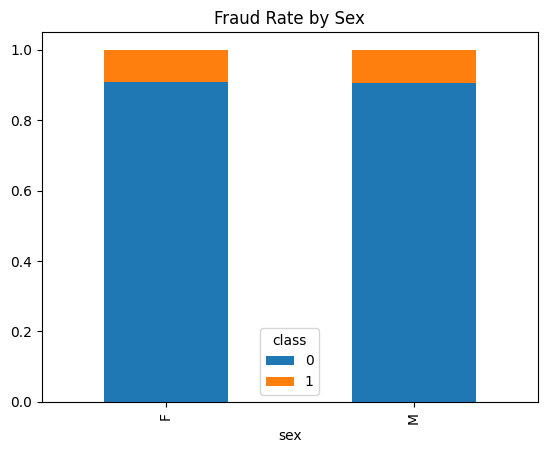

In [34]:
pd.crosstab(df['sex'], df['class'], normalize='index').plot(kind='bar', stacked=True)
plt.title("Fraud Rate by Sex")
plt.show()

In [35]:
class_counts = df['class'].value_counts()
print(class_counts)

print("\nFraud percentage:")
print(df['class'].value_counts(normalize=True) * 100)

class
0    136961
1     14151
Name: count, dtype: int64

Fraud percentage:
class
0    90.635423
1     9.364577
Name: proportion, dtype: float64


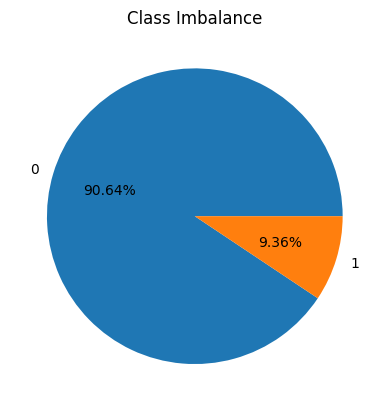

In [36]:
df['class'].value_counts().plot(kind='pie', autopct='%1.2f%%')
plt.title("Class Imbalance")
plt.ylabel("")
plt.show()

In [37]:
# Convert IP to integer (if needed)
df['ip_address_int'] = df['ip_address'].astype(int)

In [39]:
df['ip_address_int'] = df['ip_address'].astype(int)

In [40]:
import ipaddress

df['ip_address_int'] = df['ip_address'].fillna(0).astype(int)

In [44]:
import pandas as pd

ip_country = pd.read_csv(r"C:\Data\data\raw\IpAddress_to_Country.csv")

print(ip_country.head())

   lower_bound_ip_address  upper_bound_ip_address    country
0              16777216.0                16777471  Australia
1              16777472.0                16777727      China
2              16777728.0                16778239      China
3              16778240.0                16779263  Australia
4              16779264.0                16781311      China


In [45]:
df = df.sort_values('ip_address_int')
ip_country = ip_country.sort_values('lower_bound_ip_address')

In [47]:
df = df.sort_values('ip_address_int')
ip_country = ip_country.sort_values('lower_bound_ip_address')

In [48]:
df['ip_address_int'] = df['ip_address_int'].astype(int)
ip_country['lower_bound_ip_address'] = ip_country['lower_bound_ip_address'].astype(int)
ip_country['upper_bound_ip_address'] = ip_country['upper_bound_ip_address'].astype(int)

In [49]:
merged = pd.merge_asof(
    df,
    ip_country,
    left_on='ip_address_int',
    right_on='lower_bound_ip_address',
    direction='backward'
)

In [50]:
merged = pd.merge_asof(
    df,
    ip_country,
    left_on='ip_address_int',
    right_on='lower_bound_ip_address',
    direction='backward'
)

merged = merged[
    merged['ip_address_int'] <= merged['upper_bound_ip_address']
]

In [51]:
merged

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,time_diff,ip_address_int,lower_bound_ip_address,upper_bound_ip_address,country
634,247547,2015-06-28 03:00:34,2015-08-09 03:57:29,47,KIXYSVCHIPQBR,SEO,Safari,F,30,1.677886e+07,0,3632215.0,16778864,1.677824e+07,1.677926e+07,Australia
635,220737,2015-01-28 14:21:11,2015-02-11 20:28:28,15,PKYOWQKWGJNJI,SEO,Chrome,F,34,1.684205e+07,0,1231637.0,16842045,1.680998e+07,1.684275e+07,Thailand
636,390400,2015-03-19 20:49:09,2015-04-11 23:41:23,44,LVCSXLISZHVUO,Ads,IE,M,29,1.684366e+07,0,1997534.0,16843656,1.684326e+07,1.684378e+07,China
637,69592,2015-02-24 06:11:57,2015-05-23 16:40:14,55,UHAUHNXXUADJE,Direct,Chrome,F,30,1.693873e+07,0,7640897.0,16938732,1.692467e+07,1.694106e+07,China
638,174987,2015-07-07 12:58:11,2015-11-03 04:04:30,51,XPGPMOHIDRMGE,SEO,Chrome,F,37,1.697198e+07,0,10249579.0,16971984,1.694106e+07,1.697382e+07,Thailand
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131724,33024,2015-04-12 21:07:04,2015-05-12 22:42:35,56,PRYMTRKRYXEZC,Direct,Opera,F,18,3.757992e+09,0,2597731.0,3757992063,3.757965e+09,3.758031e+09,China
131725,62132,2015-08-07 10:46:59,2015-08-27 22:35:23,36,XAZBVQEIGZMVM,Direct,Chrome,F,36,3.758008e+09,0,1770504.0,3758008198,3.757965e+09,3.758031e+09,China
131726,363333,2015-02-09 07:56:12,2015-03-19 16:55:29,37,LPFTNUDBBWDVD,SEO,FireFox,M,42,3.758019e+09,0,3315557.0,3758018545,3.757965e+09,3.758031e+09,China
131727,340800,2015-05-10 19:31:22,2015-05-15 09:27:33,9,VUDMWVCEHXMCV,Direct,Chrome,F,37,3.758029e+09,0,395771.0,3758029146,3.757965e+09,3.758031e+09,China


In [52]:
print(merged['country'].isnull().sum())
print(merged.head())

0
     user_id         signup_time       purchase_time  purchase_value  \
634   247547 2015-06-28 03:00:34 2015-08-09 03:57:29              47   
635   220737 2015-01-28 14:21:11 2015-02-11 20:28:28              15   
636   390400 2015-03-19 20:49:09 2015-04-11 23:41:23              44   
637    69592 2015-02-24 06:11:57 2015-05-23 16:40:14              55   
638   174987 2015-07-07 12:58:11 2015-11-03 04:04:30              51   

         device_id  source browser sex  age    ip_address  class   time_diff  \
634  KIXYSVCHIPQBR     SEO  Safari   F   30  1.677886e+07      0   3632215.0   
635  PKYOWQKWGJNJI     SEO  Chrome   F   34  1.684205e+07      0   1231637.0   
636  LVCSXLISZHVUO     Ads      IE   M   29  1.684366e+07      0   1997534.0   
637  UHAUHNXXUADJE  Direct  Chrome   F   30  1.693873e+07      0   7640897.0   
638  XPGPMOHIDRMGE     SEO  Chrome   F   37  1.697198e+07      0  10249579.0   

     ip_address_int  lower_bound_ip_address  upper_bound_ip_address    country  
634

In [53]:
# Validate range
merged = merged[merged['ip_address_int'] <= merged['upper_bound_ip_address']]


In [54]:
# Handle missing countries
merged['country'] = merged['country'].fillna('Unknown')

In [55]:
df['signup_time'] = pd.to_datetime(df['signup_time'])
df['purchase_time'] = pd.to_datetime(df['purchase_time'])

In [56]:
df['hour_of_day'] = df['purchase_time'].dt.hour

In [57]:
df['day_of_week'] = df['purchase_time'].dt.dayofweek

In [58]:
df['time_since_signup'] = (
    df['purchase_time'] - df['signup_time']
).dt.total_seconds()

In [59]:
df['time_since_signup_min'] = df['time_since_signup'] / 60

In [60]:
df['user_txn_count'] = df.groupby('user_id')['user_id'].transform('count')

In [61]:
df = df.sort_values(['user_id', 'purchase_time'])

In [63]:
df = df.sort_values(['user_id', 'purchase_time'])

In [74]:
df = df.sort_values(['user_id', 'purchase_time'])

# compute time differences within each user
df['time_diff'] = df.groupby('user_id')['purchase_time'].diff().dt.total_seconds()

# mark fast activity
df['fast_txn'] = (df['time_diff'] < 3600).astype(int)

# approximate 24h activity pressure
df['txn_velocity'] = df.groupby('user_id')['fast_txn'].transform('sum')

In [66]:
df = df.sort_values(['user_id', 'purchase_time'])

df['time_diff'] = df.groupby('user_id')['purchase_time'].diff().dt.total_seconds()

df['fast_repeat_flag'] = (df['time_diff'] < 3600).astype(int)

In [67]:
df['txn_velocity'] = df.groupby('user_id')['fast_repeat_flag'].transform('sum')

In [72]:
df = df.sort_values(['user_id', 'purchase_time'])

# compute time differences within each user
df['time_diff'] = df.groupby('user_id')['purchase_time'].diff().dt.total_seconds()

# mark fast activity
df['fast_txn'] = (df['time_diff'] < 3600).astype(int)

# approximate 24h activity pressure
df['txn_velocity'] = df.groupby('user_id')['fast_txn'].transform('sum')

In [75]:
df['txn_per_day'] = df.groupby(
    ['user_id', df['purchase_time'].dt.date]
)['user_id'].transform('count')

In [76]:
X = df.drop(columns=['class'])
y = df['class']

In [77]:
num_cols = [
    'purchase_value',
    'age',
    'time_since_signup',
    'user_txn_count',
    'txn_per_day',
    'time_diff',
    'txn_velocity'
]

cat_cols = [
    'source',
    'browser',
    'sex'
]

In [78]:
X[num_cols] = X[num_cols].fillna(0)
X[cat_cols] = X[cat_cols].fillna('Unknown')

In [79]:
X_cat = pd.get_dummies(X[cat_cols], drop_first=True)

In [86]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_num = pd.DataFrame(
    scaler.fit_transform(X[num_cols]),
    columns=num_cols
)

In [87]:
X_final = pd.concat([X_num, X_cat], axis=1)

In [88]:
print(X_final.shape)
print(X_final.head())

(151112, 14)
   purchase_value       age  time_since_signup  user_txn_count  txn_per_day  \
0        0.931338 -0.944649          -0.437279             0.0          0.0   
1        0.221836  0.563874           1.633857             0.0          0.0   
2        0.549298 -0.944649           0.555032             0.0          0.0   
3        1.367955 -1.408809          -1.458852             0.0          0.0   
4       -0.105627 -1.640890          -0.096136             0.0          0.0   

   time_diff  txn_velocity  source_Direct  source_SEO  browser_FireFox  \
0        0.0           0.0          False        True            False   
1        0.0           0.0          False       False            False   
2        0.0           0.0          False        True            False   
3        0.0           0.0          False        True            False   
4        0.0           0.0          False       False            False   

   browser_IE  browser_Opera  browser_Safari  sex_M  
0       False

In [89]:
df['class'].value_counts()

class
0    136961
1     14151
Name: count, dtype: int64

In [90]:
df['class'].value_counts(normalize=True) * 100

class
0    90.635423
1     9.364577
Name: proportion, dtype: float64

In [91]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [93]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [94]:
print("Before SMOTE:")
print(y_train.value_counts())

Before SMOTE:
class
0    109568
1     11321
Name: count, dtype: int64


In [95]:
print("After SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

After SMOTE:
class
0    109568
1    109568
Name: count, dtype: int64


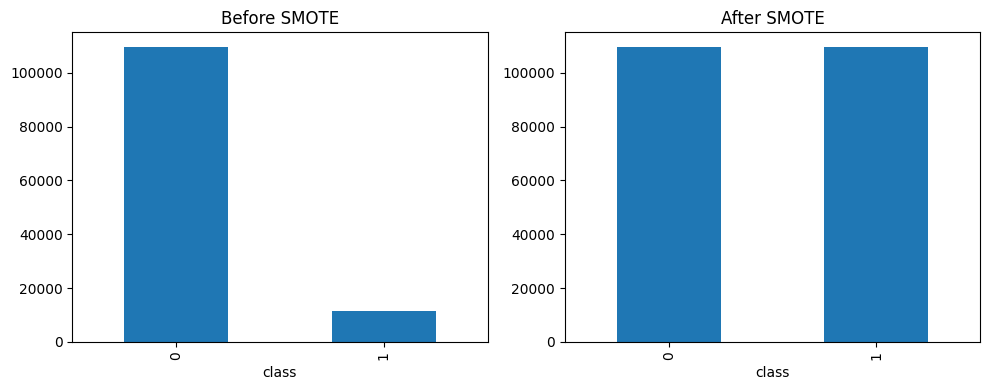

In [96]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10,4))

y_train.value_counts().plot(kind='bar', ax=ax[0], title="Before SMOTE")
pd.Series(y_train_resampled).value_counts().plot(kind='bar', ax=ax[1], title="After SMOTE")

plt.tight_layout()
plt.show()